# Evaluate a checkpoint on the test set

Loads a Lightning checkpoint, runs inference over `data/<root>/test/`, and produces:
- Scalar metrics (macro + per-class)
- Confusion matrix (raw + row-normalized)
- Per-class ROC and PR curves
- A gallery of TB false negatives — the most clinically dangerous error mode

Set `CONFIG_PATH` and `CKPT_PATH` in the first code cell, then *Run All*.

## 1. Setup

In [ ]:
%load_ext autoreload
%autoreload 2

import os
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / 'src'))
os.chdir(REPO_ROOT)  # so relative paths in the YAML (data/tbx11k, experiments/...) resolve

# === EDIT THESE ===
CONFIG_PATH = REPO_ROOT / 'experiments/configs/flipr_resnet18_colab.yaml'
CKPT_PATH = REPO_ROOT / 'experiments/results/resnet18-colab-001/checkpoints/resnet18-flipr-full.ckpt'
# Override the dataset root from the YAML if your local path differs from the YAML.
DATA_ROOT_OVERRIDE: str | None = None  # e.g. 'data/tbx11k-classification-3-class-seed-42'
# ==================

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

from tb_classifier.config import load_config
from tb_classifier.data import build_test_loader
from tb_classifier.training import TBLitModule
from tb_classifier.utils.metrics import CLASS_NAMES

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'CWD: {Path.cwd()}')
print(f'Config: {CONFIG_PATH}')
print(f'Checkpoint: {CKPT_PATH}')
assert CKPT_PATH.is_file(), f'Checkpoint not found: {CKPT_PATH}'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Device: cpu
CWD: /Users/ravisaulog/projects/tb-classifier
Config: /Users/ravisaulog/projects/tb-classifier/experiments/configs/resnet18_colab.yaml
Checkpoint: /Users/ravisaulog/projects/tb-classifier/experiments/results/resnet18-colab-001/checkpoints/tbx11k-resnet18.ckpt


## 2. Load config, test data, and checkpoint

In [10]:
cfg = load_config(CONFIG_PATH)
if DATA_ROOT_OVERRIDE:
    cfg.data.root = DATA_ROOT_OVERRIDE

test_loader = build_test_loader(cfg.data)
print(f'Test set size: {len(test_loader.dataset)} images')
print(f'Class counts: {test_loader.dataset.class_counts()}')

module = TBLitModule.load_from_checkpoint(
    str(CKPT_PATH),
    model_cfg=cfg.model,
    training_cfg=cfg.training,
    map_location=device,
)
module.eval()
module.to(device)
print(f'Loaded {cfg.model.arch} with {sum(p.numel() for p in module.parameters()):,} params')

Test set size: 1260 images
Class counts: {0: 570, 1: 570, 2: 120}
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/ravisaulog/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 42.4MB/s]


Loaded resnet18 with 11,178,051 params


## 3. Run inference

Collects logits, probabilities, predictions, labels, and file paths for every test image.

In [11]:
all_logits, all_labels, all_files = [], [], []
with torch.inference_mode():
    for batch in test_loader:
        images = batch['image'].to(device, non_blocking=True)
        logits = module(images)
        all_logits.append(logits.cpu())
        all_labels.append(batch['label'])
        all_files.extend(batch['file_name'])

logits = torch.cat(all_logits)
labels = torch.cat(all_labels).numpy()
probs = torch.softmax(logits, dim=1).numpy()
preds = probs.argmax(axis=1)
files = np.array(all_files)

print(f'logits {logits.shape} | probs {probs.shape} | labels {labels.shape}')

/Users/ravisaulog/projects/tb-classifier/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


logits torch.Size([1260, 3]) | probs (1260, 3) | labels (1260,)


## 4. Scalar metrics

For TB screening the headline numbers are **TB sensitivity** (recall on the TB class — proportion of TB cases caught) and **TB specificity** (TPR for ruling out disease). Macro AUROC summarizes overall ranking quality.

In [ ]:
import pandas as pd

n_classes = len(CLASS_NAMES)
labels_onehot = np.eye(n_classes)[labels]

rows = []
for i, name in enumerate(CLASS_NAMES):
    cls_pred = (preds == i)
    cls_true = (labels == i)
    tp = int((cls_pred & cls_true).sum())
    fp = int((cls_pred & ~cls_true).sum())
    fn = int((~cls_pred & cls_true).sum())
    tn = int((~cls_pred & ~cls_true).sum())
    sens = tp / (tp + fn) if (tp + fn) else 0.0 
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    f1 = 2 * prec * sens / (prec + sens) if (prec + sens) else 0.0
    auc = roc_auc_score(labels_onehot[:, i], probs[:, i])
    rows.append({
        'class': name, 'support': int(cls_true.sum()),
        'sensitivity': sens, 'specificity': spec,
        'precision': prec, 'f1': f1, 'auroc': auc,
    })

per_class = pd.DataFrame(rows).set_index('class')
macro = per_class[['sensitivity', 'specificity', 'precision', 'f1', 'auroc']].mean()
macro['accuracy'] = float((preds == labels).mean())
macro['auroc_macro_ovr'] = roc_auc_score(labels_onehot, probs, multi_class='ovr', average='macro')

print('Per-class:')
display(per_class.style.format({c: '{:.3f}' for c in per_class.columns if c != 'support'}))
print('\nMacro:')
display(macro.to_frame('value'))

Per-class:


,support,sensitivity,specificity,precision,f1,auroc
class,,,,,,
healthy,570,0.995,0.997,0.996,0.996,1.000
sick-non-tb,570,0.996,0.993,0.991,0.994,1.000
tb,120,0.983,1.000,1.000,0.992,1.000



Macro:


,value
sensitivity,0.991520
specificity,0.996618
precision,0.995920
f1,0.993694
auroc,0.999787
accuracy,0.994444
auroc_macro_ovr,0.999787


## 5. Confusion matrix

Rows = true class, columns = predicted class. The right plot is row-normalized — each row sums to 1 and the diagonal is per-class recall.

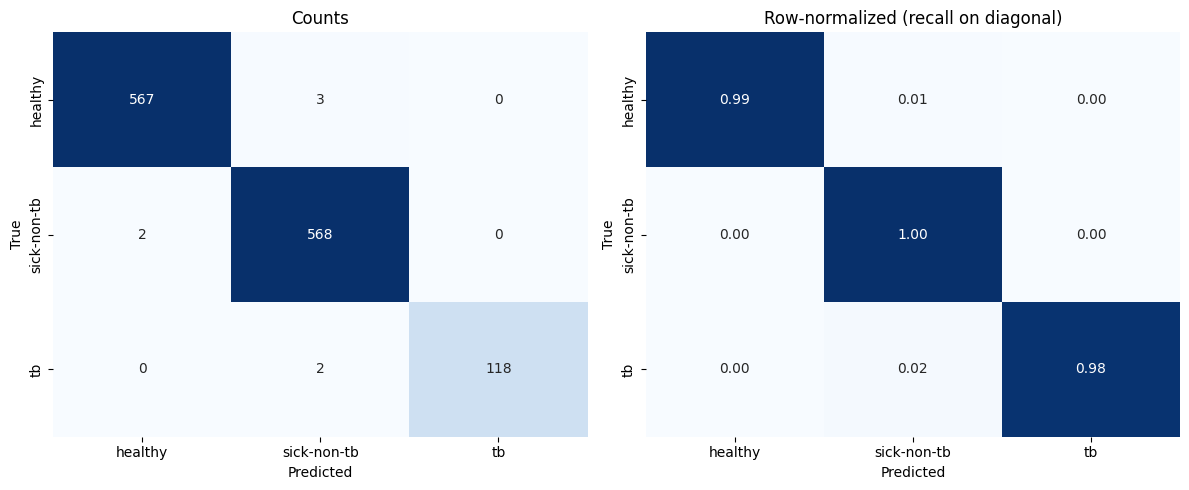

In [13]:
cm = confusion_matrix(labels, preds, labels=list(range(n_classes)))
cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, mat, title, fmt in [
    (axes[0], cm, 'Counts', 'd'),
    (axes[1], cm_norm, 'Row-normalized (recall on diagonal)', '.2f'),
]:
    sns.heatmap(
        mat, annot=True, fmt=fmt, cmap='Blues', cbar=False,
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax,
    )
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(title)
plt.tight_layout()
plt.show()

## 6. ROC curves (one-vs-rest)

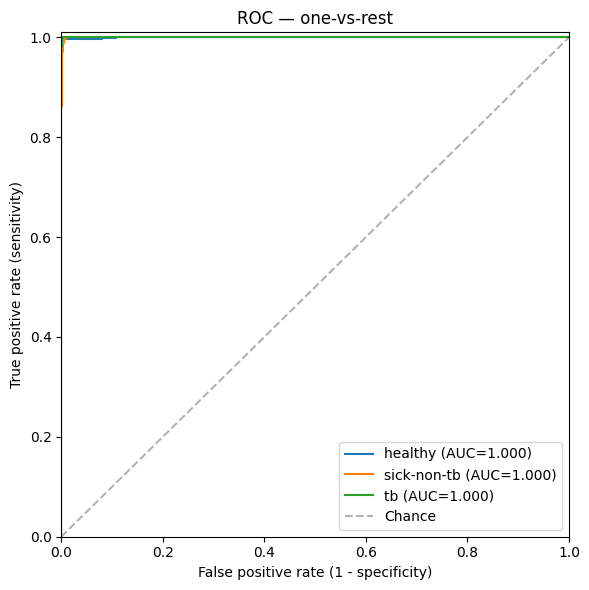

In [14]:
fig, ax = plt.subplots(figsize=(6, 6))
for i, name in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(labels_onehot[:, i], probs[:, i])
    auc = roc_auc_score(labels_onehot[:, i], probs[:, i])
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Chance')
ax.set_xlabel('False positive rate (1 - specificity)')
ax.set_ylabel('True positive rate (sensitivity)')
ax.set_title('ROC — one-vs-rest')
ax.legend(loc='lower right')
ax.set_xlim(0, 1); ax.set_ylim(0, 1.01)
plt.tight_layout()
plt.show()

## 7. Precision-Recall curves

More informative than ROC when classes are imbalanced — TB is the minority class in TBX11K.

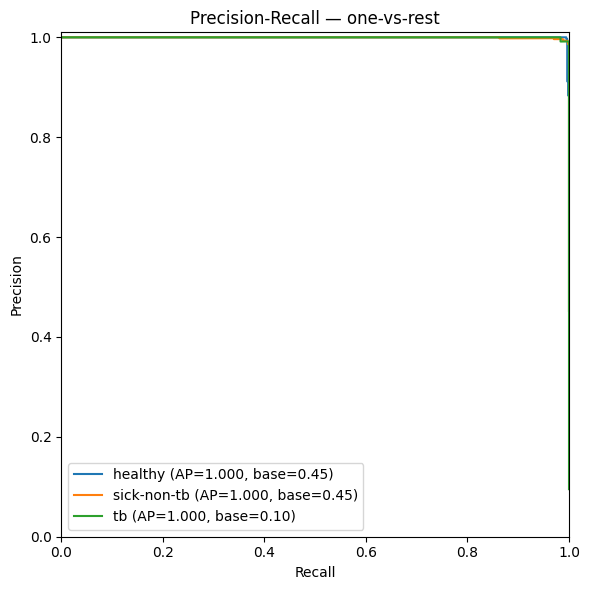

In [15]:
fig, ax = plt.subplots(figsize=(6, 6))
for i, name in enumerate(CLASS_NAMES):
    prec_curve, rec_curve, _ = precision_recall_curve(labels_onehot[:, i], probs[:, i])
    ap = average_precision_score(labels_onehot[:, i], probs[:, i])
    base_rate = labels_onehot[:, i].mean()
    ax.plot(rec_curve, prec_curve, label=f'{name} (AP={ap:.3f}, base={base_rate:.2f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall — one-vs-rest')
ax.legend(loc='lower left')
ax.set_xlim(0, 1); ax.set_ylim(0, 1.01)
plt.tight_layout()
plt.show()

## 8. sklearn classification report

Standard precision/recall/F1/support table — useful for a stable text artifact to paste into PRs or run notes.

In [16]:
print(classification_report(labels, preds, target_names=list(CLASS_NAMES), digits=3))

              precision    recall  f1-score   support

     healthy      0.996     0.995     0.996       570
 sick-non-tb      0.991     0.996     0.994       570
          tb      1.000     0.983     0.992       120

    accuracy                          0.994      1260
   macro avg      0.996     0.992     0.994      1260
weighted avg      0.994     0.994     0.994      1260



## 9. TB false negatives — clinically dangerous misses

True TB cases the model failed to flag, sorted by TB probability (lowest first — these are the most confidently missed). Eyeballing these often reveals mislabeled images, weird acquisitions, or systematic failure modes worth fixing.

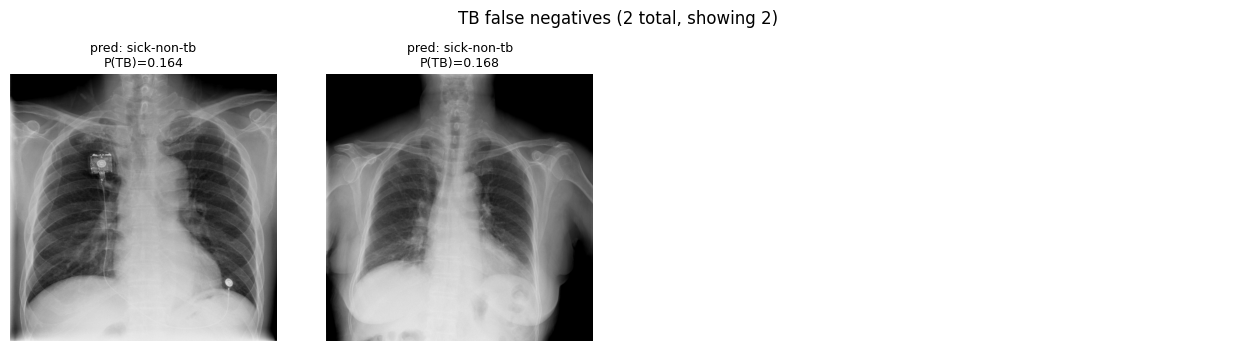

In [17]:
import cv2

TB_IDX = list(CLASS_NAMES).index('tb')
tb_mask = (labels == TB_IDX)
missed_mask = tb_mask & (preds != TB_IDX)
missed_indices = np.where(missed_mask)[0]

if len(missed_indices) == 0:
    print('No TB false negatives — every TB case in the test set was correctly flagged.')
else:
    order = missed_indices[np.argsort(probs[missed_indices, TB_IDX])]
    n_show = min(12, len(order))
    show = order[:n_show]
    cols = 4
    rows = int(np.ceil(n_show / cols))
    data_root = Path(cfg.data.root)
    test_dir = data_root / 'test'

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.2, rows * 3.4))
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        ax.axis('off')
    for ax, idx in zip(axes, show):
        img_path = test_dir / files[idx]
        img = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
        if img is None:
            ax.set_title(f'(missing)\n{files[idx]}', fontsize=8)
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        pred_name = CLASS_NAMES[preds[idx]]
        ax.set_title(
            f'pred: {pred_name}\nP(TB)={probs[idx, TB_IDX]:.3f}',
            fontsize=9,
        )
    plt.suptitle(f'TB false negatives ({len(missed_indices)} total, showing {n_show})', y=1.02)
    plt.tight_layout()
    plt.show()